In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# Time Series ARIMA

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [30]:
df = pd.read_csv('../datasets/sales_forcast.csv')

df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(1377, 12)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Cost_Price,Discount,Profit
0,1130,2020-01-01,9423,Male,39,Electronics,5,2773.0,13879.69,2073.09,12,3514.25
1,1100,2020-01-02,1986,Male,30,Beauty,4,3371.0,13489.58,2653.51,12,2875.54
2,1062,2020-01-02,6947,Female,58,Electronics,8,2827.0,22368.22,2076.01,10,5760.12
3,1346,2020-01-03,1128,Male,25,Sports,2,1616.0,3227.66,1184.32,18,859.02
4,1385,2020-01-06,4247,Female,19,Clothing,3,2517.0,7881.04,2030.32,10,1790.10


In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [32]:
df.set_index('Date', inplace=True)

In [33]:
monthly_sales = df['Total Amount'].resample('M').sum()

monthly_sales.head()

Date
2020-01-31    345778.74
2020-02-29    295724.09
2020-03-31    275309.22
2020-04-30    279292.59
2020-05-31    265326.35
Freq: M, Name: Total Amount, dtype: float64

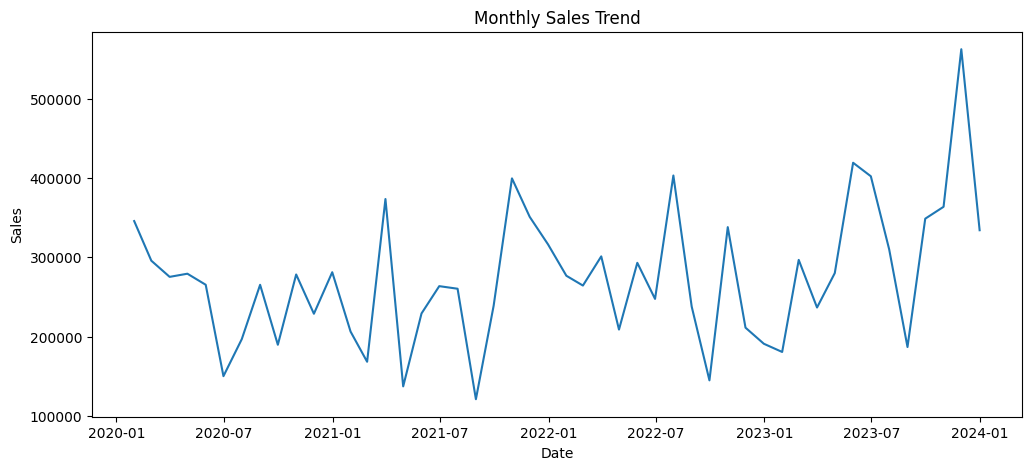

In [34]:

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [35]:
model = ARIMA(monthly_sales, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Total Amount   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -600.377
Date:                Thu, 18 Jun 2026   AIC                           1206.754
Time:                        17:55:07   BIC                           1212.305
Sample:                    01-31-2020   HQIC                          1208.843
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1197      0.223      0.536      0.592      -0.318       0.558
ma.L1         -0.8675      0.153     -5.685      0.000      -1.167      -0.568
sigma2      8.031e+09   3.56e-12   2.26e+21      0.0

In [36]:
future_12 = model_fit.forecast(steps=12)

print(future_12)

2024-01-31    334020.442201
2024-02-29    333999.407003
2024-03-31    333996.889307
2024-04-30    333996.587965
2024-05-31    333996.551897
2024-06-30    333996.547580
2024-07-31    333996.547064
2024-08-31    333996.547002
2024-09-30    333996.546994
2024-10-31    333996.546994
2024-11-30    333996.546993
2024-12-31    333996.546993
Freq: M, Name: predicted_mean, dtype: float64


In [37]:
forecast_df = pd.DataFrame({
    'Month': future_12.index,
    'Predicted_Sales': future_12.values
})

forecast_df

,Month,Predicted_Sales
0,2024-01-31,334020.442201
1,2024-02-29,333999.407003
2,2024-03-31,333996.889307
3,2024-04-30,333996.587965
4,2024-05-31,333996.551897
5,2024-06-30,333996.547580
6,2024-07-31,333996.547064
7,2024-08-31,333996.547002
8,2024-09-30,333996.546994
9,2024-10-31,333996.546994


In [ ]:
total_2024_sales = future_12.sum()

print("Predicted Total Sales for 2024 =", round(total_2024_sales,2))

Predicted Total Sales for 2024 = 4007985.72


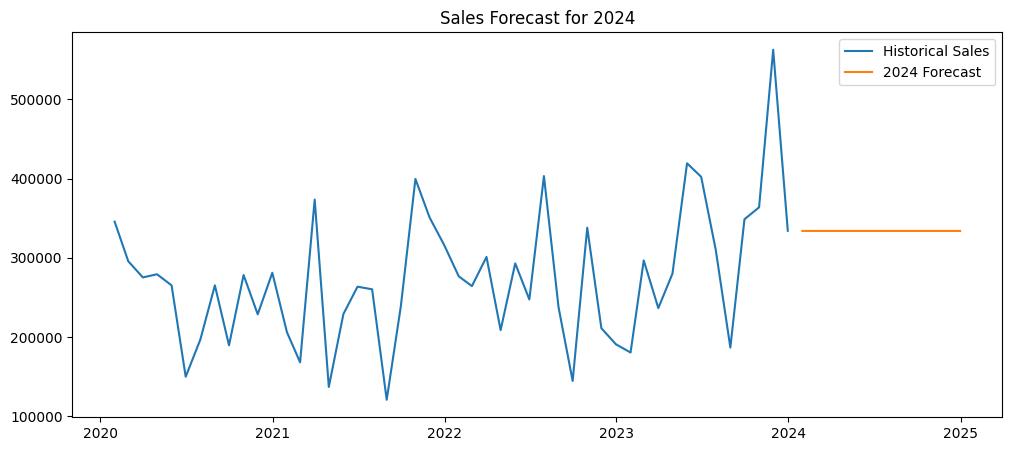

In [40]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales, label='Historical Sales')
plt.plot(future_12.index, future_12, label='2024 Forecast')

plt.legend()
plt.title('Sales Forecast for 2024')

plt.show()

In [ ]:
import pickle

pickle.dump(model_fit, open('arima_sales_model.pkl', 'wb'))

print("ARIMA Model Saved Successfully")

ARIMA Model Saved Successfully


In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

train = monthly_sales[:-12]
test = monthly_sales[-12:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(((test - forecast) ** 2).mean())
mape = mean_absolute_percentage_error(test, forecast)

accuracy = (1 - mape) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", round(mape*100,2), "%")
print("Accuracy:", round(accuracy,2), "%")

MAE: 98933.61262124596
RMSE: 124882.58515083975
MAPE: 28.16 %
Accuracy: 71.84 %


In [ ]:
# "The ARIMA model learns patterns from historical monthly sales data and predicts future sales.
#  In my project, I used sales data from 2020–2023, converted it into monthly sales,
# trained an ARIMA(1,1,1) model, and forecasted sales for the next 12 months of 2024.
#  The model predicted an annual sales revenue of approximately ₹40.08 Lakhs with an accuracy of 71.84%."

# ARIMA uses past sales trends and patterns to predict future monthly and yearly sales.

# Dataset Size: 1377 Rows, 12 Columns
# Historical Data Used: 2020–2023
# Forecast Period: Jan 2024 – Dec 2024
# Predicted Monthly Sales: 12 Future Months
# Predicted Annual Sales (2024): ₹4,007,985.72 (~₹40.08 Lakhs)
# Model Accuracy: 71.84%

# Working Flow

# Historical Sales Data (2020–2023)
#                 ↓
#             ARIMA Model
#                 ↓
# Monthly Forecast (Jan 2024 – Dec 2024)
                # ↓
# Total Yearly Sales Forecast (2024)